<a href="https://colab.research.google.com/github/EdgarPrueba/Portafolio1/blob/main/NB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB5 — Detección de señales OFDM mediante aprendizaje automático

## 1. Introducción

La detección de símbolos es una etapa fundamental de un receptor digital, ya que permite recuperar la información transmitida a partir de la señal recibida. En un sistema OFDM, los datos se distribuyen entre múltiples subportadoras y pueden verse afectados por ruido, interferencia y las variaciones introducidas por el canal de propagación.

En este notebook se estudia la detección de símbolos **16-QAM** utilizando señales OFDM obtenidas mediante mediciones reales con radios **Software-Defined Radio (SDR)**. El objetivo es comparar un detector convencional basado en la distancia a los centroides de las clases observadas con un modelo de aprendizaje automático tipo **MLP (Multi-Layer Perceptron)**.

De forma simplificada, la señal recibida puede representarse como

$$
r = hs + n + i
$$

donde:

* $s$ representa el símbolo transmitido;
* $h$ representa el efecto del canal;
* $n$ representa el ruido;
* $i$ representa la interferencia;
* $r$ corresponde a la señal recibida.

Para 16-QAM, cada símbolo pertenece a un conjunto de 16 posibles estados:

$$
s \in \mathcal{S}_{16QAM}
$$

Después de estimar y compensar el efecto del canal, el detector convencional asigna cada símbolo recibido a la clase cuyo centroide presenta la menor distancia euclídea:

$$
\hat{s}
=
\arg\min_{c \in \{0,\ldots,15\}}
\left\|
\mathbf{r}-\boldsymbol{\mu}_c
\right\|^2
$$

donde $\boldsymbol{\mu}_c$ representa el centroide de la clase $c$, calculado utilizando únicamente las muestras del conjunto de entrenamiento.

Por otra parte, el modelo MLP aprende una función de decisión a partir de las componentes en fase y cuadratura:

$$
[I,Q]\rightarrow\hat{s}
$$

La comparación se realizará utilizando la **tasa de error de bit (BER)** en función del **SINR (Signal-to-Interference-plus-Noise Ratio)**:

$$
BER =
\frac{N_{\text{bits erróneos}}}
{N_{\text{bits transmitidos}}}
$$

La hipótesis física principal es que, al aumentar el SINR, la señal útil debería resultar más distinguible frente al ruido y la interferencia, produciendo una disminución del BER:

$$
SINR\uparrow
\quad\Rightarrow\quad
BER\downarrow
$$

El experimento utiliza el **SDR OFDM Dataset v1**, un conjunto de datos obtenido mediante transmisión inalámbrica con SDR. El dataset contiene muestras I/Q recibidas después del DFT, los bits transmitidos asociados y una medida de SINR para cada TTI. Las mediciones corresponden a condiciones reales de propagación, incluyendo escenarios NLOS y movilidad a velocidad peatonal.

En este notebook se utilizará únicamente una fracción controlada del dataset para mantener el experimento reproducible y compatible con Google Colab.


# 1. Configuración e inspección del dataset SDR OFDM

En esta primera etapa se configura el entorno de trabajo y se carga el **SDR OFDM Dataset v1**, obtenido directamente desde su repositorio oficial en GitHub. El dataset contiene muestras complejas de una transmisión OFDM medida mediante SDR, junto con las etiquetas de los símbolos transmitidos y su correspondiente nivel de SINR.

Se establece una semilla fija para garantizar la reproducibilidad de los experimentos y se inspecciona la estructura de los datos antes de realizar cualquier procesamiento.

En particular, se verifican las dimensiones de las muestras I/Q, la cantidad de bits asociados a cada TTI y los niveles de SINR disponibles. Esta inspección permite confirmar que los datos son compatibles con el problema de detección de símbolos 16-QAM planteado en este notebook.


In [ ]:
# ============================================================
# CELDA 1 — Configuración e inspección del dataset SDR OFDM
# ============================================================

import os
import sys
import random
import urllib.request

import numpy as np
import torch


# ------------------------------------------------------------
# 1. Reproducibilidad
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo: {'cuda' if torch.cuda.is_available() else 'cpu'}")


# ------------------------------------------------------------
# 2. Dataset
# ------------------------------------------------------------

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "rikluost/sdr_ofdm_dataset_v1/main/"
    "ofdm_valset_4_8_sdr.pth"
)

DATA_PATH = "/content/ofdm_valset_4_8_sdr.pth"

if not os.path.exists(DATA_PATH):
    print("\nDescargando dataset desde GitHub...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Descarga completada.")
else:
    print("\nEl dataset ya existe en la sesión de Colab.")


# ------------------------------------------------------------
# 3. Obtener el módulo config requerido por el dataset
# ------------------------------------------------------------

CONFIG_URL = (
    "https://raw.githubusercontent.com/"
    "rikluost/sdr_ofdm_dataset_v1/main/config.py"
)

CONFIG_PATH = "/content/config.py"

if not os.path.exists(CONFIG_PATH):
    print("Descargando config.py del repositorio...")
    urllib.request.urlretrieve(CONFIG_URL, CONFIG_PATH)
    print("config.py descargado.")
else:
    print("config.py ya existe en la sesión.")


# Asegurar que Python pueda encontrar config.py
if "/content" not in sys.path:
    sys.path.append("/content")


# ------------------------------------------------------------
# 4. Cargar dataset
# ------------------------------------------------------------

dataset = torch.load(
    DATA_PATH,
    map_location="cpu",
    weights_only=False
)

print("\nDataset cargado correctamente.")
print(f"Tipo de objeto: {type(dataset)}")
print(f"Número de TTIs: {len(dataset)}")


# ------------------------------------------------------------
# 5. Inspeccionar la primera muestra
# ------------------------------------------------------------

pdsch_iq, labels, sinr = dataset[0]

print("\n--- Primera muestra ---")

print(f"Tipo IQ:     {type(pdsch_iq)}")
print(f"Tipo labels: {type(labels)}")
print(f"Tipo SINR:   {type(sinr)}")

print(f"\nIQ shape:     {pdsch_iq.shape}")
print(f"IQ dtype:     {pdsch_iq.dtype}")

print(f"\nLabels shape: {labels.shape}")
print(f"Labels dtype: {labels.dtype}")

print(f"\nSINR:         {sinr}")


# ------------------------------------------------------------
# 6. Inspección de dimensiones y valores
# ------------------------------------------------------------

print("\n--- Verificación de estructura ---")

print(f"TTI completo:       {pdsch_iq.shape}")
print(f"Bits asociados:     {labels.numel()}")
print(f"Bits por símbolo:   {labels.shape[-1]}")

print(
    f"Valor mínimo IQ (real): "
    f"{pdsch_iq.real.min().item():.4f}"
)

print(
    f"Valor máximo IQ (real): "
    f"{pdsch_iq.real.max().item():.4f}"
)

print(
    f"Valor mínimo IQ (imag): "
    f"{pdsch_iq.imag.min().item():.4f}"
)

print(
    f"Valor máximo IQ (imag): "
    f"{pdsch_iq.imag.max().item():.4f}"
)


# ------------------------------------------------------------
# 7. Valores de SINR disponibles
# ------------------------------------------------------------

sinr_values = []

for idx in range(len(dataset)):

    _, _, sample_sinr = dataset[idx]

    if torch.is_tensor(sample_sinr):
        sample_sinr = sample_sinr.item()

    sinr_values.append(float(sample_sinr))


sinr_values = np.array(sinr_values)

unique_sinr = np.unique(sinr_values)


print("\n--- SINR disponible en el dataset ---")

print(
    f"Mínimo:        "
    f"{sinr_values.min():.3f} dB"
)

print(
    f"Máximo:        "
    f"{sinr_values.max():.3f} dB"
)

print(
    f"Niveles únicos: "
    f"{len(unique_sinr)}"
)

print("\nValores:")

print(unique_sinr)


# ------------------------------------------------------------
# 8. Resumen
# ------------------------------------------------------------

print("\n================ RESUMEN ================")

print(
    f"TTIs disponibles:      "
    f"{len(dataset)}"
)

print(
    f"Forma IQ por TTI:      "
    f"{tuple(pdsch_iq.shape)}"
)

print(
    f"Forma labels por TTI:  "
    f"{tuple(labels.shape)}"
)

print(
    f"Tipo IQ:               "
    f"{pdsch_iq.dtype}"
)

print(
    f"Tipo labels:           "
    f"{labels.dtype}"
)

print(
    f"SINR mínimo:           "
    f"{sinr_values.min():.3f} dB"
)

print(
    f"SINR máximo:           "
    f"{sinr_values.max():.3f} dB"
)

print(
    f"Niveles SINR:          "
    f"{len(unique_sinr)}"
)

print("==========================================")

PyTorch: 2.11.0+cpu
Dispositivo: cpu

El dataset ya existe en la sesión de Colab.
config.py ya existe en la sesión.

Dataset cargado correctamente.
Tipo de objeto: <class 'config.CustomDataset'>
Número de TTIs: 742

--- Primera muestra ---
Tipo IQ:     <class 'torch.Tensor'>
Tipo labels: <class 'torch.Tensor'>
Tipo SINR:   <class 'float'>

IQ shape:     torch.Size([14, 128])
IQ dtype:     torch.complex64

Labels shape: torch.Size([1400, 4])
Labels dtype: torch.float32

SINR:         7.0

--- Verificación de estructura ---
TTI completo:       torch.Size([14, 128])
Bits asociados:     5600
Bits por símbolo:   4
Valor mínimo IQ (real): -0.8338
Valor máximo IQ (real): 0.8850
Valor mínimo IQ (imag): -0.8542
Valor máximo IQ (imag): 0.8580

--- SINR disponible en el dataset ---
Mínimo:        5.100 dB
Máximo:        30.400 dB
Niveles únicos: 221

Valores:
[ 5.1  5.2  5.3  5.4  5.5  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4
  6.5  6.6  6.7  6.8  6.9  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7

# 2. Preparación de símbolos OFDM y etiquetas 16-QAM

A partir de los TTIs seleccionados se extraen únicamente los **símbolos de datos 16-QAM** utilizados para la detección. Cada TTI contiene 14 símbolos OFDM y una FFT de 128 puntos, de los cuales se consideran las 102 subportadoras activas del bloque utilizado por el dataset.

La subportadora de corriente continua (DC) se elimina y, en el tercer símbolo OFDM, también se excluyen las 14 posiciones correspondientes a pilotos. De esta forma se obtienen exactamente **1400 símbolos de datos por TTI**, cada uno asociado con cuatro bits de información correspondientes a la modulación 16-QAM.

Finalmente, los símbolos complejos se representan mediante sus componentes **I/Q**, obteniendo una matriz de características de dos dimensiones para posteriormente utilizarla tanto en el detector clásico como en el modelo de aprendizaje automático.


In [ ]:
# ============================================================
# CELDA 2 — Preparación de símbolos OFDM y etiquetas 16-QAM
# ============================================================

import numpy as np
import torch


# ------------------------------------------------------------
# 1. Parámetros del sistema
# ------------------------------------------------------------

N_TTI = 400
N_OFDM_SYMBOLS = 14
FFT_SIZE = 128

N_OFFSET = 13
N_ACTIVE_WITH_DC = 102
N_ACTIVE = 101

DC_INDEX = 64

PILOT_SYMBOL = 2

# Posiciones de piloto dentro del bloque de 102 subportadoras activas
PILOT_INDICES = np.array(
    [0, 8, 16, 24, 32, 40, 48, 56,
     64, 72, 80, 88, 96, 101]
)

BITS_PER_QAM = 4
N_DATA_SYMBOLS = 1400


# ------------------------------------------------------------
# 2. Selección de TTIs
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

selected_indices = rng.choice(
    len(dataset),
    size=N_TTI,
    replace=False
)

selected_indices = np.sort(selected_indices)

print("TTIs seleccionados:", len(selected_indices))
print("Primeros índices:", selected_indices[:10])


# ------------------------------------------------------------
# 3. Función de extracción de símbolos de datos
# ------------------------------------------------------------

def extract_data_symbols(pdsch_iq):
    """
    Extrae los 1400 símbolos 16-QAM de datos de un TTI.

    Entrada:
        pdsch_iq -> tensor complejo [14, 128]

    Salida:
        data_symbols -> ndarray complejo [1400]
    """

    iq = pdsch_iq.cpu().numpy()

    # --------------------------------------------------------
    # 3.1 Seleccionar las 102 subportadoras activas
    # --------------------------------------------------------

    active = iq[
        :,
        N_OFFSET:N_OFFSET + N_ACTIVE_WITH_DC
    ]

    assert active.shape == (14, 102)


    # --------------------------------------------------------
    # 3.2 Eliminar la subportadora DC
    # --------------------------------------------------------

    # Posición del DC dentro del bloque activo de 102
    dc_position = DC_INDEX - N_OFFSET

    assert dc_position == 51

    active_no_dc = np.delete(
        active,
        dc_position,
        axis=1
    )

    assert active_no_dc.shape == (14, 101)


    # --------------------------------------------------------
    # 3.3 Ajustar posiciones de pilotos después de eliminar DC
    # --------------------------------------------------------

    # Los pilotos están definidos originalmente sobre las
    # 102 subportadoras activas, incluyendo el DC.
    #
    # Como el DC fue eliminado, los pilotos posteriores al DC
    # se desplazan una posición hacia la izquierda.

    pilot_positions_no_dc = np.where(
        PILOT_INDICES > dc_position,
        PILOT_INDICES - 1,
        PILOT_INDICES
    )

    # Ningún piloto coincide con el DC
    assert not np.any(PILOT_INDICES == dc_position)

    # Deben existir exactamente 14 pilotos
    assert len(pilot_positions_no_dc) == 14

    # Todas las posiciones deben estar dentro de [0, 100]
    assert np.all(
        (pilot_positions_no_dc >= 0) &
        (pilot_positions_no_dc < N_ACTIVE)
    )


    # --------------------------------------------------------
    # 3.4 Extraer únicamente símbolos de datos
    # --------------------------------------------------------

    data_symbols = []

    for ofdm_symbol in range(N_OFDM_SYMBOLS):

        row = active_no_dc[ofdm_symbol]

        if ofdm_symbol == PILOT_SYMBOL:

            # En el tercer símbolo se eliminan los 14 pilotos
            data_mask = np.ones(
                N_ACTIVE,
                dtype=bool
            )

            data_mask[pilot_positions_no_dc] = False

            row_data = row[data_mask]

            # 101 subportadoras - 14 pilotos = 87 datos
            assert len(row_data) == 87

        else:

            # En los otros símbolos, las 101 subportadoras
            # restantes corresponden a datos.
            row_data = row

            assert len(row_data) == 101

        data_symbols.extend(row_data)


    # --------------------------------------------------------
    # 3.5 Verificación final
    # --------------------------------------------------------

    data_symbols = np.asarray(
        data_symbols,
        dtype=np.complex64
    )

    # 13 símbolos × 101 datos + 1 símbolo × 87 datos
    # = 1313 + 87 = 1400
    assert len(data_symbols) == 1400

    return data_symbols


# ------------------------------------------------------------
# 4. Extraer datos de los TTIs seleccionados
# ------------------------------------------------------------

X_complex = []
Y_bits = []
SINR = []


for idx in selected_indices:

    pdsch_iq, labels, sinr = dataset[idx]

    symbols = extract_data_symbols(pdsch_iq)

    # Verificación fundamental
    assert len(symbols) == N_DATA_SYMBOLS

    X_complex.append(symbols)

    Y_bits.append(
        labels.cpu().numpy().astype(np.int64)
    )

    SINR.append(float(sinr))


X_complex = np.asarray(X_complex)
Y_bits = np.asarray(Y_bits)
SINR = np.asarray(SINR)


# ------------------------------------------------------------
# 5. Verificaciones
# ------------------------------------------------------------

print("\n--- Datos preparados ---")

print(f"X_complex shape: {X_complex.shape}")
print(f"Y_bits shape:    {Y_bits.shape}")
print(f"SINR shape:      {SINR.shape}")

print(
    f"\nSímbolos por TTI: "
    f"{X_complex.shape[1]}"
)

print(
    f"Bits por símbolo: "
    f"{Y_bits.shape[2]}"
)

print(
    f"Bits por TTI: "
    f"{Y_bits.shape[1] * Y_bits.shape[2]}"
)


# ------------------------------------------------------------
# 6. Verificación de consistencia
# ------------------------------------------------------------

assert X_complex.shape == (
    N_TTI,
    N_DATA_SYMBOLS
)

assert Y_bits.shape == (
    N_TTI,
    N_DATA_SYMBOLS,
    BITS_PER_QAM
)

assert len(SINR) == N_TTI


print("\n✓ Estructura consistente.")


# ------------------------------------------------------------
# 7. Conversión a características I/Q
# ------------------------------------------------------------

X = np.column_stack(
    (
        X_complex.real.reshape(-1),
        X_complex.imag.reshape(-1)
    )
)

Y = Y_bits.reshape(
    -1,
    BITS_PER_QAM
)


print("\n--- Matrices para ML ---")

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

print("\nPrimeras muestras I/Q:")
print(X[:5])

print("\nPrimeras etiquetas:")
print(Y[:5])

TTIs seleccionados: 400
Primeros índices: [ 3  6 11 13 14 15 16 17 23 24]

--- Datos preparados ---
X_complex shape: (400, 1400)
Y_bits shape:    (400, 1400, 4)
SINR shape:      (400,)

Símbolos por TTI: 1400
Bits por símbolo: 4
Bits por TTI: 5600

✓ Estructura consistente.

--- Matrices para ML ---
X shape: (560000, 2)
Y shape: (560000, 4)

Primeras muestras I/Q:
[[ 0.58051395 -0.084405  ]
 [-0.02575475  0.6522957 ]
 [-0.11886293  0.61835045]
 [ 0.72606367  0.6876275 ]
 [-0.19517046 -0.49347237]]

Primeras etiquetas:
[[0 0 1 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 0 0 0]
 [1 0 1 1]]


# 3. Estimación de canal, detección y comparación con aprendizaje automático

En esta etapa se realiza la detección de los símbolos 16-QAM mediante dos estrategias: un **detector clásico basado en centroides** y una red neuronal tipo **MLP**. Antes de la detección se estima el canal utilizando los pilotos conocidos presentes en el tercer símbolo OFDM de cada TTI.

La respuesta del canal se obtiene a partir de la relación entre los símbolos piloto recibidos y los valores piloto conocidos. Posteriormente, se interpola la respuesta compleja del canal sobre las subportadoras activas y se aplica una ecualización Zero-Forcing (ZF):

$$
\hat{s}_k=\frac{r_k}{\hat{H}_k}
$$

donde \(r_k\) representa el símbolo recibido y \(\hat{H}_k\) la respuesta estimada del canal.

Los TTIs se dividen en un **70 % para entrenamiento y un 30 % para prueba**, manteniendo la separación a nivel de TTI para evitar que símbolos pertenecientes al mismo bloque aparezcan simultáneamente en ambos conjuntos.

Como línea base, se calculan los centroides de las 16 clases 16-QAM utilizando únicamente los datos de entrenamiento. Cada símbolo de prueba se asigna a la clase cuyo centroide presenta la menor distancia euclídea.

En paralelo, se entrena un MLP que recibe las componentes **I/Q** de cada símbolo y produce una clasificación entre las 16 clases posibles. Finalmente, ambos métodos se evalúan mediante **BER y accuracy**, incluyendo la BER para los diferentes niveles de SINR disponibles en el conjunto de prueba.


TTIs de entrenamiento: 280
TTIs de prueba: 120

X entrenamiento: (392000, 2)
X prueba:        (168000, 2)
Epoch 1/8 - Loss: 2.0145
Epoch 2/8 - Loss: 1.0893
Epoch 3/8 - Loss: 0.9395
Epoch 4/8 - Loss: 0.8831
Epoch 5/8 - Loss: 0.8400
Epoch 6/8 - Loss: 0.8147
Epoch 7/8 - Loss: 0.8014
Epoch 8/8 - Loss: 0.7941

================ RESULTADOS ================
Baseline - BER: 0.097835 | Accuracy: 0.7521
MLP      - BER: 0.097863 | Accuracy: 0.7517


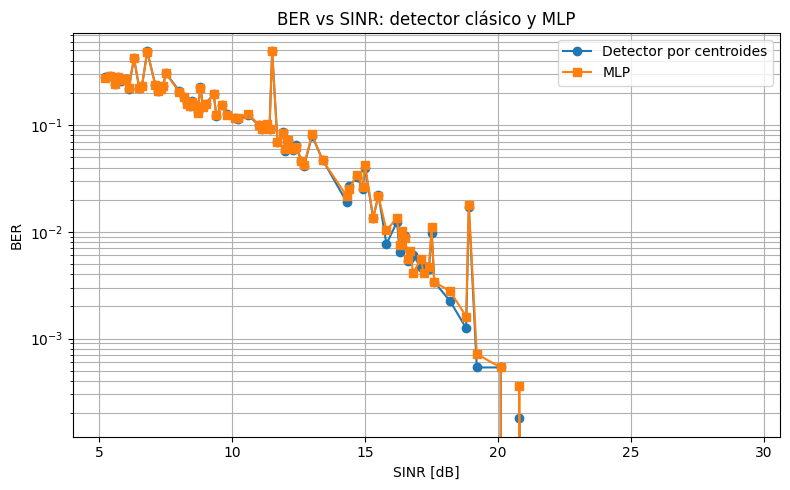

In [ ]:
# ============================================================
# CELDA 3: Estimación de canal, detección y comparación con MLP
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Parámetros
# ------------------------------------------------------------

TRAIN_RATIO = 0.70
BATCH_SIZE = 4096
EPOCHS = 8
LEARNING_RATE = 1e-3

# Posiciones de pilotos en el bloque activo de 102 subportadoras
PILOT_INDICES = np.array([
    0, 8, 16, 24, 32, 40, 48,
    56, 64, 72, 80, 88, 96, 101
])

PILOT_VALUES = np.array([
    -0.7-0.7j, -0.7+0.7j,
     0.7-0.7j,  0.7+0.7j,
    -0.7-0.7j, -0.7+0.7j,
     0.7-0.7j,  0.7+0.7j,
    -0.7-0.7j, -0.7+0.7j,
     0.7-0.7j,  0.7+0.7j,
    -0.7-0.7j, -0.7+0.7j
], dtype=np.complex64)

# ------------------------------------------------------------
# 2. Separación de entrenamiento y prueba por TTI
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

n_train = int(N_TTI * TRAIN_RATIO)

train_ttis = selected_indices[:n_train]
test_ttis = selected_indices[n_train:]

train_mask = np.isin(selected_indices, train_ttis)
test_mask = np.isin(selected_indices, test_ttis)

print(f"TTIs de entrenamiento: {n_train}")
print(f"TTIs de prueba: {N_TTI - n_train}")

# ------------------------------------------------------------
# 3. Reconstrucción del bloque activo y eliminación de DC
# ------------------------------------------------------------

# X_complex contiene únicamente los 1400 símbolos de datos.
# Para estimar el canal necesitamos volver al dominio de las
# 102 posiciones activas, incluyendo DC y pilotos.

X_equalized = np.zeros_like(X_complex, dtype=np.complex64)

# Índices de las posiciones piloto después de eliminar DC.
pilot_positions = PILOT_INDICES.copy()

# La posición DC = 51 dentro del bloque activo de 102.
DC_ACTIVE_INDEX = 51

pilot_positions_no_dc = np.array([
    p - 1 if p > DC_ACTIVE_INDEX else p
    for p in pilot_positions
])

# Índices de datos dentro de las 101 subportadoras después de
# eliminar DC.
all_active_no_dc = np.arange(N_ACTIVE)

data_positions = np.setdiff1d(
    all_active_no_dc,
    pilot_positions_no_dc
)

# ------------------------------------------------------------
# 4. Extracción de los datos recibidos desde el dataset
# ------------------------------------------------------------

for tti in range(N_TTI):

    # Recuperar la matriz original [14, 128]
    iq = dataset[int(selected_indices[tti])][0].numpy()

    # Bloque activo de 102 subportadoras:
    # FFT indices 13 ... 114
    active = iq[:, N_OFFSET:N_OFFSET + N_ACTIVE_WITH_DC]

    # Símbolo piloto: tercer símbolo OFDM
    received_pilots = active[
        PILOT_SYMBOL,
        PILOT_INDICES
    ]

    # --------------------------------------------------------
    # 5. Estimación de canal en las posiciones piloto
    # --------------------------------------------------------

    H_pilots = received_pilots / PILOT_VALUES

    # --------------------------------------------------------
    # 6. Interpolación compleja del canal
    # --------------------------------------------------------

    active_positions = np.arange(N_ACTIVE_WITH_DC)

    H_real = np.interp(
        active_positions,
        PILOT_INDICES,
        H_pilots.real
    )

    H_imag = np.interp(
        active_positions,
        PILOT_INDICES,
        H_pilots.imag
    )

    H_active = H_real + 1j * H_imag

    # Eliminar DC
    H_no_dc = np.delete(H_active, DC_ACTIVE_INDEX)

    # --------------------------------------------------------
    # 7. Reconstruir los 1400 símbolos de datos
    # --------------------------------------------------------

    received_data = []

    for ofdm_symbol in range(N_OFDM_SYMBOLS):

        symbol_active = iq[
            ofdm_symbol,
            N_OFFSET:N_OFFSET + N_ACTIVE_WITH_DC
        ]

        symbol_no_dc = np.delete(
            symbol_active,
            DC_ACTIVE_INDEX
        )

        # Eliminar pilotos únicamente del símbolo 2
        if ofdm_symbol == PILOT_SYMBOL:
            symbol_data = symbol_no_dc[data_positions]
            H_data = H_no_dc[data_positions]
        else:
            symbol_data = symbol_no_dc
            H_data = H_no_dc

        # Ecualización ZF:
        # r = Hs + n  ->  s_hat = r/H
        H_safe = H_data.copy()
        H_safe[np.abs(H_safe) < 1e-6] = 1e-6 + 0j

        equalized = symbol_data / H_safe

        received_data.append(equalized)

    # 13*101 + 87 = 1400
    X_equalized[tti] = np.concatenate(received_data)

# ------------------------------------------------------------
# 8. Conversión a I/Q para el modelo de ML
# ------------------------------------------------------------

X_eq = np.column_stack((
    X_equalized.real.reshape(-1),
    X_equalized.imag.reshape(-1)
)).astype(np.float32)

Y_class = Y_class.astype(np.int64)

# Máscara por TTI para conservar la separación original
train_symbol_mask = np.repeat(train_mask, N_DATA_SYMBOLS)
test_symbol_mask = np.repeat(test_mask, N_DATA_SYMBOLS)

X_train = X_eq[train_symbol_mask]
Y_train = Y_class[train_symbol_mask]

X_test = X_eq[test_symbol_mask]
Y_test = Y_class[test_symbol_mask]

SINR_test = np.repeat(
    SINR[test_mask],
    N_DATA_SYMBOLS
)

print(f"\nX entrenamiento: {X_train.shape}")
print(f"X prueba:        {X_test.shape}")

# ------------------------------------------------------------
# 9. Línea base: centroides observados
# ------------------------------------------------------------

# Los centroides se calculan únicamente con entrenamiento.
# Esto evita utilizar información de los TTIs de prueba.

centroids = np.zeros((16, 2), dtype=np.float32)

for c in range(16):
    class_samples = X_train[Y_train == c]

    centroids[c] = np.mean(class_samples, axis=0)

# Clasificación por distancia euclídea
distances = (
    np.sum(
        (X_test[:, None, :] - centroids[None, :, :]) ** 2,
        axis=2
    )
)

pred_baseline = np.argmin(distances, axis=1)

# ------------------------------------------------------------
# 10. MLP: I/Q -> clase 16-QAM
# ------------------------------------------------------------

torch.manual_seed(SEED)

X_train_t = torch.tensor(X_train)
Y_train_t = torch.tensor(Y_train)

X_test_t = torch.tensor(X_test)
Y_test_t = torch.tensor(Y_test)

train_loader = DataLoader(
    TensorDataset(X_train_t, Y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True
)

model = nn.Sequential(
    nn.Linear(2, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 16)
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# ------------------------------------------------------------
# 11. Entrenamiento
# ------------------------------------------------------------

model.train()

for epoch in range(EPOCHS):

    total_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        output = model(xb)

        loss = criterion(output, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)

    epoch_loss = total_loss / len(X_train)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"- Loss: {epoch_loss:.4f}"
    )

# ------------------------------------------------------------
# 12. Predicción MLP
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    logits = model(X_test_t)
    pred_mlp = torch.argmax(logits, dim=1).numpy()

# ------------------------------------------------------------
# 13. Conversión de clases a bits
# ------------------------------------------------------------

def classes_to_bits(classes):
    return np.column_stack((
        (classes >> 3) & 1,
        (classes >> 2) & 1,
        (classes >> 1) & 1,
        classes & 1
    ))

Y_test_bits = classes_to_bits(Y_test)
baseline_bits = classes_to_bits(pred_baseline)
mlp_bits = classes_to_bits(pred_mlp)

# ------------------------------------------------------------
# 14. BER global
# ------------------------------------------------------------

ber_baseline = np.mean(
    baseline_bits != Y_test_bits
)

ber_mlp = np.mean(
    mlp_bits != Y_test_bits
)

acc_baseline = np.mean(
    pred_baseline == Y_test
)

acc_mlp = np.mean(
    pred_mlp == Y_test
)

print("\n================ RESULTADOS ================")

print(
    f"Baseline - BER: {ber_baseline:.6f} "
    f"| Accuracy: {acc_baseline:.4f}"
)

print(
    f"MLP      - BER: {ber_mlp:.6f} "
    f"| Accuracy: {acc_mlp:.4f}"
)

# ------------------------------------------------------------
# 15. BER por SINR
# ------------------------------------------------------------

unique_sinr = np.unique(SINR[test_mask])

ber_baseline_sinr = []
ber_mlp_sinr = []

sinr_valid = []

for snr_value in unique_sinr:

    mask = np.isclose(
        SINR_test,
        snr_value
    )

    if np.sum(mask) == 0:
        continue

    ber_b = np.mean(
        baseline_bits[mask] != Y_test_bits[mask]
    )

    ber_m = np.mean(
        mlp_bits[mask] != Y_test_bits[mask]
    )

    sinr_valid.append(snr_value)
    ber_baseline_sinr.append(ber_b)
    ber_mlp_sinr.append(ber_m)

sinr_valid = np.array(sinr_valid)
ber_baseline_sinr = np.array(ber_baseline_sinr)
ber_mlp_sinr = np.array(ber_mlp_sinr)

# ------------------------------------------------------------
# 16. Figura principal: BER vs SINR
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.semilogy(
    sinr_valid,
    ber_baseline_sinr,
    "o-",
    label="Detector por centroides"
)

plt.semilogy(
    sinr_valid,
    ber_mlp_sinr,
    "s-",
    label="MLP"
)

plt.xlabel("SINR [dB]")
plt.ylabel("BER")
plt.title("BER vs SINR: detector clásico y MLP")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Visualización de las constelaciones 16-QAM

Para complementar la comparación cuantitativa se visualizan las constelaciones recibidas después de la estimación de canal y la ecualización ZF.

Se seleccionan dos TTIs representativos: uno correspondiente al **menor SINR** disponible y otro al **mayor SINR**. La comparación permite observar visualmente cómo la calidad del canal afecta la distribución de las muestras I/Q.

A bajos niveles de SINR se espera una mayor dispersión de los puntos alrededor de las posiciones ideales de los símbolos 16-QAM. Al aumentar el SINR, las agrupaciones deberían presentar una separación más definida, facilitando la detección de los símbolos y explicando físicamente la reducción de la BER observada en la figura anterior.


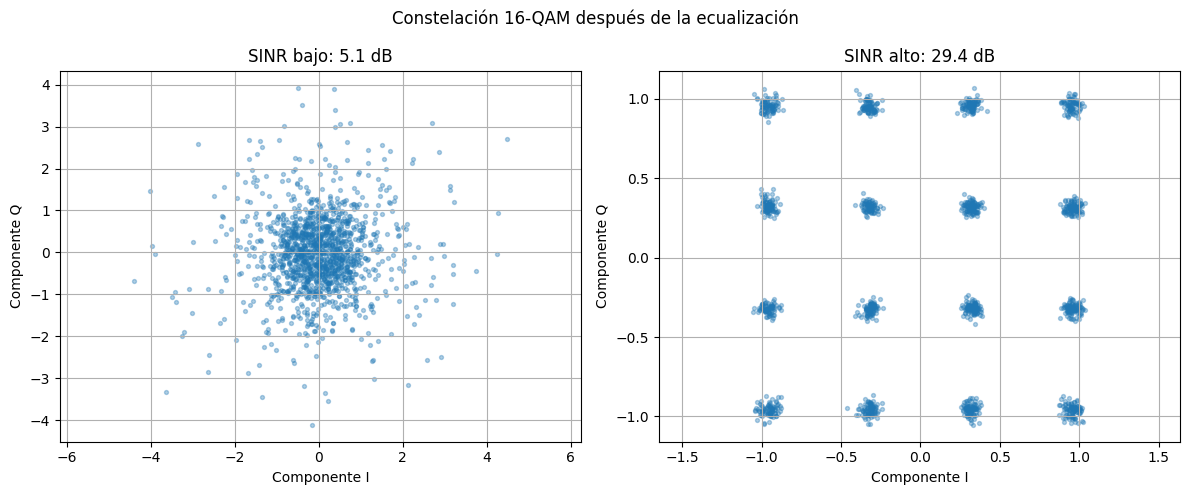

In [ ]:
# ============================================================
# CELDA 4: Constelaciones 16-QAM antes y después de la mejora
# ============================================================

# Seleccionar un TTI de SINR bajo y uno de SINR alto
idx_low = np.argmin(SINR)
idx_high = np.argmax(SINR)

# Símbolos ecualizados correspondientes
symbols_low = X_equalized[idx_low]
symbols_high = X_equalized[idx_high]

# Limitar la visualización para mantener la figura legible
MAX_POINTS = 3000

rng_plot = np.random.default_rng(SEED)

if len(symbols_low) > MAX_POINTS:
    low_plot = rng_plot.choice(
        symbols_low,
        size=MAX_POINTS,
        replace=False
    )
else:
    low_plot = symbols_low

if len(symbols_high) > MAX_POINTS:
    high_plot = rng_plot.choice(
        symbols_high,
        size=MAX_POINTS,
        replace=False
    )
else:
    high_plot = symbols_high

# ------------------------------------------------------------
# Visualización
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.scatter(
    low_plot.real,
    low_plot.imag,
    s=8,
    alpha=0.35
)

plt.xlabel("Componente I")
plt.ylabel("Componente Q")
plt.title(f"SINR bajo: {SINR[idx_low]:.1f} dB")
plt.grid(True)
plt.axis("equal")

plt.subplot(1, 2, 2)

plt.scatter(
    high_plot.real,
    high_plot.imag,
    s=8,
    alpha=0.35
)

plt.xlabel("Componente I")
plt.ylabel("Componente Q")
plt.title(f"SINR alto: {SINR[idx_high]:.1f} dB")
plt.grid(True)
plt.axis("equal")

plt.suptitle("Constelación 16-QAM después de la ecualización")
plt.tight_layout()
plt.show()



La comparación de las constelaciones permite observar directamente el efecto de la calidad del canal sobre la detección de símbolos 16-QAM. Para valores bajos de SINR, las muestras presentan una mayor dispersión alrededor de las posiciones de los símbolos debido a la presencia de ruido e interferencia. Al aumentar el SINR, la dispersión disminuye y los grupos de símbolos se vuelven más definidos, lo que explica físicamente la reducción de la BER observada.

La comparación entre el detector clásico basado en centroides y el MLP muestra un resultado relevante: ambos métodos alcanzaron prácticamente el mismo desempeño. El detector clásico obtuvo una BER de 0.0978 y una accuracy de 75.21 %, mientras que el MLP obtuvo una BER de 0.0979 y una accuracy de 75.17 %. Por tanto, bajo las condiciones evaluadas, el aprendizaje automático no produjo una mejora significativa respecto al método convencional.

Este resultado evidencia que la utilidad del aprendizaje automático depende del problema específico y de la representación de los datos. Después de la estimación del canal mediante pilotos y la ecualización, la información contenida en las componentes I/Q es suficientemente estructurada para que un detector sencillo basado en distancia pueda realizar la clasificación con un desempeño comparable al de la red neuronal.

En consecuencia, el experimento no demuestra que el MLP sea superior al detector clásico, sino que ambos pueden resolver adecuadamente la tarea de detección en este escenario. La principal ventaja del análisis con ML consiste en mostrar que una red neuronal puede aprender una función de decisión a partir de los datos, mientras que el método clásico mantiene la ventaja de una menor complejidad y una interpretación física directa.

Finalmente, la tendencia observada de BER decreciente con el aumento del SINR confirma la relación fundamental entre calidad de la señal y desempeño de la comunicación. Esto permite conectar de forma directa el modelo físico del canal con los resultados obtenidos mediante aprendizaje automático y constituye el principal resultado experimental de este notebook.
